<a href="https://colab.research.google.com/github/ronan-cunha/machine-learning-course/blob/main/Notebooks/aula_10_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml, load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
# ==============================================================================
# ETAPA 1: Carregar Dataset Real (Diabetes)
# ==============================================================================
# O dataset possui 442 observações e 10 variáveis preditoras clínicas:
# age (idade), sex (sexo), bmi (IMC), bp (pressão arterial média)
# s1 a s6 (seis medições do soro sanguíneo, ex: colesterol total, LDL, HDL, triglicérides, glicose)
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
# ==============================================================================
# ETAPA 2: Divisão entre Treino e Teste
# ==============================================================================
X = df.drop(columns=["target"])
y = df["target"]

feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Amostras de Treino: {X_train.shape[0]} | Amostras de Teste: {X_test.shape[0]}\n")

Amostras de Treino: 353 | Amostras de Teste: 89



In [7]:
# ==============================================================================
# ETAPA 3: Instanciar e Treinar o Modelo Random Forest
# ==============================================================================
rf_model = RandomForestRegressor(
    n_estimators=100,
    criterion = 'squared_error', #absolute_error
    max_features="sqrt",
    max_depth=6,
    min_samples_split=4,
    min_samples_leaf=2,
    oob_score=True,
    random_state=42,
    n_jobs=-1,
)

In [8]:
rf_model.fit(X_train, y_train)
print(f"R² Out-Of-Bag (OOB Score): {rf_model.oob_score_:.4f}\n")

R² Out-Of-Bag (OOB Score): 0.4434



In [9]:
# ==============================================================================
# ETAPA 4: Avaliação no Conjunto de Teste
# ==============================================================================
y_pred = rf_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Métricas de Avaliação no Teste ---")
print(f"MAE  (Erro Médio Absoluto): {mae:.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.2f}")
print(f"R²   (Coeficiente de Determinação): {r2:.4f}\n")

--- Métricas de Avaliação no Teste ---
MAE  (Erro Médio Absoluto): 43.69
RMSE (Raiz do Erro Quadrático Médio): 53.27
R²   (Coeficiente de Determinação): 0.4644



In [10]:
# ==============================================================================
# ETAPA 5: Importância das Variáveis (MDI)
# ==============================================================================
df_importance = pd.DataFrame(
    {"Feature": feature_names, "Importancia": rf_model.feature_importances_}
).sort_values(by="Importancia", ascending=False)

print("--- Importância das Variáveis no Dataset Diabetes (MDI) ---")
print(df_importance.to_string(index=False), "\n")

--- Importância das Variáveis no Dataset Diabetes (MDI) ---
Feature  Importancia
    bmi     0.282130
     s5     0.202569
     bp     0.126313
     s4     0.083286
     s6     0.081094
     s3     0.079195
     s2     0.050806
     s1     0.048261
    age     0.035815
    sex     0.010530 



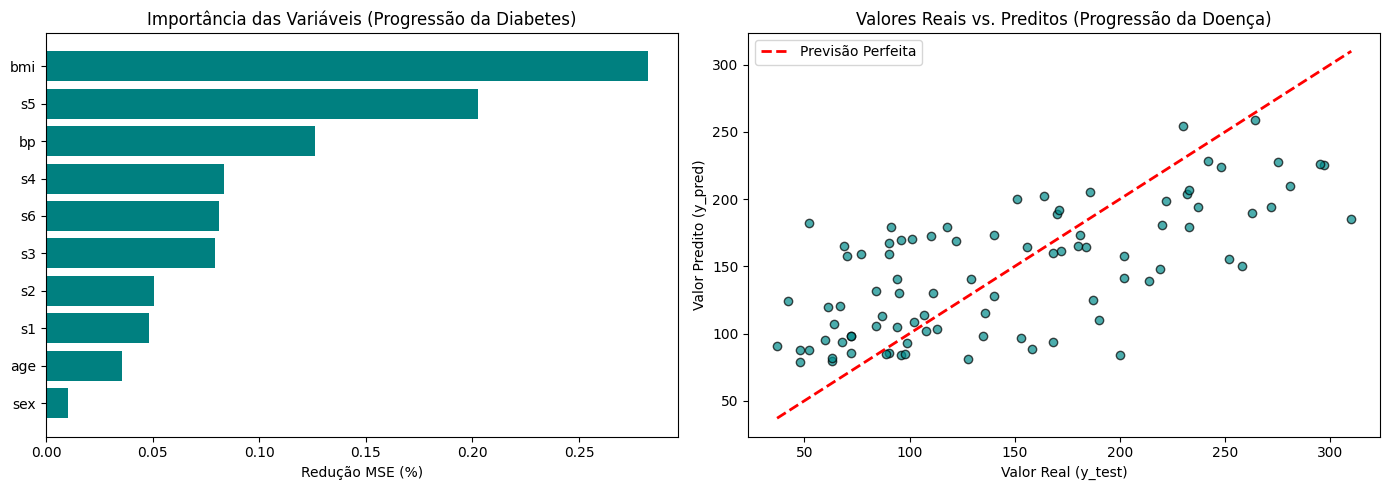

In [11]:

# ==============================================================================
# ETAPA 6: Visualização Gráfica
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Importância das Variáveis
axes[0].barh(
    df_importance["Feature"], df_importance["Importancia"], color="teal"
)
axes[0].invert_yaxis()
axes[0].set_title("Importância das Variáveis (Progressão da Diabetes)")
axes[0].set_xlabel("Redução MSE (%)")

# Gráfico 2: Valores Reais vs. Preditos
axes[1].scatter(y_test, y_pred, alpha=0.7, color="darkcyan", edgecolors="k")
axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Previsão Perfeita",
)
axes[1].set_title("Valores Reais vs. Preditos (Progressão da Doença)")
axes[1].set_xlabel("Valor Real (y_test)")
axes[1].set_ylabel("Valor Predito (y_pred)")
axes[1].legend()

plt.tight_layout()
plt.show()